In [1]:
import re
import pickle
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import mlflow
import optuna
import nltk
import pymorphy3

from tqdm.auto import tqdm
from nltk.corpus import stopwords
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, vstack
from transformers import AutoTokenizer, AutoModel
from implicit.als import AlternatingLeastSquares
from optuna.integration.mlflow import MLflowCallback
from mlflow.utils.mlflow_tags import MLFLOW_PARENT_RUN_ID
from sklearn.metrics import ndcg_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

import nltk
import pymorphy3
from nltk.corpus import stopwords
from gensim.utils import simple_preprocess

warnings.simplefilter('ignore', FutureWarning)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Перед запуском ноутбука нужно поднять

- MLflow на 127.0.0.1:5000
- Clickhouse на host: localhost /  9000  / 8123 / default

</div>

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000
EXPERIMENT_NAME = "hr-ai-scout-bert-finetune"

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")


In [3]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

torch.manual_seed(RANDOM_STATE)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(RANDOM_STATE)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Где собирали данные

- Данные собраны с hh.ru, все подробности парсинга в Load_data
- Резюме и вакансии хранятся в ClickHouse, история запросов сервиса в SQLite (hr_scout_history.db, async SQLAlchemy)
- Бизнес-метрика NDCG, заказчику HR нужна возможность отбирать соискателей по порядку наиболее подходящих, NDCG оценивает насколько хорошо модель ранжирует всех соискателей по релевантности под конкретную вакансию
- Дополнительно считаются Precision, Recall, F1 как метрики бинарной классификации с порогом 0.5
- Ниже идут дословно скопированные из ML Experiments шаги препроцессинга, фича-инжиниринга TF-IDF, train test split и baseline LogisticRegression

</div>

In [4]:
df = pd.read_csv(r"D:\Education\hr-ai-scout\total_df.csv")
df.head()

,vacancy_id,vacancy_name,vacancy_area,vacancy_experience,vacancy_employment,vacancy_schedule,vacancy_salary_from,vacancy_salary_to,vacancy_salary_currency,vacancy_salary_gross,...,resume_education,resume_courses,resume_salary,resume_age,resume_total_experience,resume_experience_months,resume_location,resume_gender,resume_applicant_status,target
0,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Казанский Авиационный Институт'],NaN,NaN,65.0,19 лет,228.0,Москва,Мужчина,Рассматривает предложения,1
1,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,"['ООО ""Открытый Учебный Центр СофтБаланс"", г. ...","['ООО ""Открытый Учебный Центр СофтБаланс"", г. ...",NaN,43.0,17 лет 4 месяца,208.0,Москва,Мужчина,Рассматривает предложения,1
2,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Орский государственный педагогический инстит...,NaN,200 000 ₽ на руки,52.0,30 лет,360.0,Москва,Женщина,NaN,1
3,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Красноярский государственный университет'],NaN,500 000 ₽ на руки,56.0,29 лет 8 месяцев,356.0,Красноярск,Мужчина,Рассматривает предложения,1
4,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Белоруский Гос. Университет Информатики и Ра...,"['SAP CIS, SAP XI', 'Школа Логистики МАДИ', 'S...",NaN,48.0,25 лет 1 месяц,301.0,Moscow,Male,NaN,1


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
- В первую очередь уберем строки, где пропущены все ключевые значения в резюме
</div>

In [5]:
t1 = df.shape[0]
df = df.dropna(subset=[
    "resume_education", "resume_last_experience_description",
    "resume_last_position", "resume_last_company_experience_period",
    "resume_total_experience", "resume_experience_months",
    "resume_location", "resume_specialization",
], how="all")


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
- Удалим еще те строки, где случился технический сбой в парсинге, где у кандидата общий опыт есть, а последний опыт не указан (и наоборот):
</div>

In [6]:
t1 = df.shape[0]
df = df.loc[~(df["resume_total_experience"].notna()
              & df["resume_last_experience_description"].isna()
              & df["resume_last_position"].isna())]
df = df.loc[~(df["resume_total_experience"].isna()
              & df["resume_last_experience_description"].notna()
              & df["resume_last_position"].notna())]


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Посмотрим на пропуски отдельно по категориальным и числовым признакам.
</div>

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('NDT')
df['resume_age'] = df['resume_age'].fillna(df['resume_age'].mean())
df['resume_experience_months'] = df['resume_experience_months'].fillna(0)
df = df.drop(['vacancy_salary_to', 'vacancy_salary_from', 'vacancy_salary_currency', 'vacancy_salary_gross'], axis=1)


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Преобразуем еще ожидаемые зарплаты
</div>

In [8]:
df['resume_salary_split'] = df['resume_salary'].apply(lambda x: x.split())
df['salary_int'] = df['resume_salary_split'].apply(
    lambda x: int(''.join(p for p in x if re.fullmatch(r'\d+', p)))
              if any(re.fullmatch(r'\d+', p) for p in x) else np.nan
)
currency_symbols = ['₽', '$', '€', '₴', '₸', '₼', '₾', 'Br', "so'm"]
rates_rub = {'₽':1.0,'$':80.85,'€':94.14,'₴':1.94,'₸':0.150,
             '₼':47.8,'₾':33.5,'Br':28.7,"so'm":0.0068}
df['currency_symbol'] = df['resume_salary_split'].apply(
    lambda x: next((s for s in x if s in currency_symbols), np.nan))
df['salary_converted'] = (df['salary_int'] * df['currency_symbol'].map(rates_rub)).fillna(0)
df['resume_salary'] = df['salary_converted']
df = df.drop(['resume_salary_split','salary_int','currency_symbol','salary_converted'], axis=1)


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Добавим дополнительный столбец с опытом работы в последней компании в месяцах для удобства
</div>

In [9]:
def experience_to_months(text):
    months = 0
    for pat in [r'(\d+)\s*год', r'(\d+)\s*лет']:
        m = re.search(pat, text)
        if m: months += int(m.group(1)) * 12
    m = re.search(r'(\d+)\s*месяц', text)
    if m: months += int(m.group(1))
    return months if months > 0 else np.nan

df['resume_last_company_experience_months'] = \
    df['resume_last_company_experience_period'].apply(experience_to_months)
df['resume_last_company_experience_months'] = \
    df['resume_last_company_experience_months'].fillna(0)


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Ограничим выбросы по зарплате, потому что ровно одно значение по ожидаемой заработоной плате = 999,999,999 (смешно, но нет)

- Ограничим опыт общий и внутри одной компании до 720 месяцев (60 лет, ничего себе уже)

- Уберем возраст > 90, не ждем, что эти кандидаты находятся в поиске вакансии
</div>

In [10]:
df = df[~(df.resume_salary > 1e7)]
df.loc[df['resume_experience_months'] > 720, 'resume_experience_months'] = 720
df.loc[df['resume_last_company_experience_months'] > 720, 'resume_last_company_experience_months'] = 720
df = df[~(df.resume_age > 90)]
df = df[~(df.resume_experience_months < df.resume_last_company_experience_months)]
df = df[~(df.resume_age < (df.resume_experience_months // 12) + 16)]

gender_map = {'Мужчина':'Мужчина','Male':'Мужчина','Женщина':'Женщина','Female':'Женщина'}
df['resume_gender'] = df['resume_gender'].apply(
    lambda x: gender_map.get(x, 'Неизвестно'))


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Добавим фичи из всех прерыдущих экспериментов, которые дали рост ndcg

</div>

In [11]:
df['location_matching'] = (df['vacancy_area'] == df['resume_location']).astype(int)

def resume_skill_count_in_vacancy(row):
    skills = row['resume_skills'].replace('[','').replace(']','').replace("'","").split(', ')
    return sum(1 for s in skills if s in row['vacancy_description'])

df['resume_skill_count_in_vacancy'] = df.apply(resume_skill_count_in_vacancy, axis=1)

def last_position_in_vacancy(row):
    bow = []
    for sep in [' ', '-', '_']:
        bow += row['resume_last_position'].split(sep=sep)
    bow = list(set(bow))
    return sum(1 for w in bow if w in row['vacancy_description']) / len(bow)

df['last_position_in_vacancy'] = df.apply(last_position_in_vacancy, axis=1)

In [12]:
def preprocess_data(df):
    
    df['vacancy_description'] = df['vacancy_description'].fillna('')
    df['resume_last_experience_description'] = df['resume_last_experience_description'].fillna('')
    
    df['vacancy_description'] = df['vacancy_description'].astype(str)
    df['resume_last_experience_description'] = df['resume_last_experience_description'].astype(str)
    
    return df

In [13]:
def save_results(df, output_file):
    df.to_csv(output_file, index=False, encoding='utf-8')

In [14]:
def calculate_cosine_similarity(embeddings1, embeddings2):
    similarities = []
    
    for i in tqdm(range(embeddings1.shape[0])):
        emb1_row = embeddings1[i]
        emb2_row = embeddings2[i]
        
        similarity = cosine_similarity(emb1_row, emb2_row)[0][0]
        similarities.append(similarity)
    
    return similarities

In [15]:
warnings.filterwarnings('ignore')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('taggers/averaged_perceptron_tagger_ru')
except LookupError:
    nltk.download('averaged_perceptron_tagger_ru')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

morph = pymorphy3.MorphAnalyzer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Puppalupa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [16]:
def lemmatize_russian(tokens):
    lemmas = []
    for token in tokens:
        parsed = morph.parse(token)[0]
        lemmas.append(parsed.normal_form)
    return lemmas

In [17]:
def tokenize_and_lemmatize(text):
    tokens = simple_preprocess(text, deacc=True, min_len=2)
    stop_words = set(stopwords.words('russian') + stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    lemmatized_tokens = lemmatize_russian(tokens)
    
    return lemmatized_tokens

In [18]:
def get_tfidf_embeddings(texts, vectorizer=None, fit=True):
    if fit:
        vectorizer = TfidfVectorizer(
            max_features=5000,
            min_df=2,
            max_df=0.8,
            ngram_range=(1, 2),
            tokenizer=tokenize_and_lemmatize,
            token_pattern=None,
            lowercase=False
        )
        embeddings = vectorizer.fit_transform(texts)
    else:
        embeddings = vectorizer.transform(texts)
    
    return embeddings, vectorizer

In [19]:
def get_tfidf_vacancy_embeddings(df, vectorizer=None):
    unique_vacancies = df[['vacancy_id', 'vacancy_description']].drop_duplicates()
    
    unique_embeddings, vectorizer = get_tfidf_embeddings(
        unique_vacancies['vacancy_description'].tolist(), 
        vectorizer=vectorizer, 
        fit=(vectorizer is None)
    )
    
    vacancy_embedding_dict = dict(zip(unique_vacancies['vacancy_id'], unique_embeddings))
    
    rows = []
    for vid in df['vacancy_id']:
        rows.append(vacancy_embedding_dict[vid])
    
    all_vacancy_embeddings = vstack(rows)
    
    return all_vacancy_embeddings, vectorizer

In [20]:
def process_similarity_scores_tfidf(df, vectorizer=None, fit=True):
    df = preprocess_data(df)
    
    experience_embeddings, tfidf_vectorizer = get_tfidf_embeddings(df['resume_last_experience_description'].tolist(), vectorizer=vectorizer, fit=fit)
    
    vacancy_embeddings, _ = get_tfidf_vacancy_embeddings(df, vectorizer=tfidf_vectorizer)
    
    similarity_scores = calculate_cosine_similarity(vacancy_embeddings, experience_embeddings)
    
    df['similarity_score_tfidf'] = similarity_scores
    
    return df, tfidf_vectorizer

In [21]:
try:
    df_tfidf = pd.read_csv('description_df_with_scores_tfidf.csv')
except:
    df_tfidf, _ = process_similarity_scores_tfidf(df.copy())
    save_results(df_tfidf, 'description_df_with_scores_tfidf.csv')

  0%|          | 0/325543 [00:00<?, ?it/s]

In [22]:
df = df.merge(df_tfidf)

In [23]:
df.head()

,vacancy_id,vacancy_name,vacancy_area,vacancy_experience,vacancy_employment,vacancy_schedule,vacancy_description,resume_id,resume_title,resume_specialization,...,resume_experience_months,resume_location,resume_gender,resume_applicant_status,target,resume_last_company_experience_months,location_matching,resume_skill_count_in_vacancy,last_position_in_vacancy,similarity_score_tfidf
0,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",6969174,ABAP-разработчик,"['Программист, разработчик']",...,228.0,Москва,Мужчина,Рассматривает предложения,1,76.0,1,3,0.666667,0.284047
1,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",9100077,"ABAP разработчик - SAP HCM, CRM, S/4HANA ERP(F...","['Программист, разработчик']",...,208.0,Москва,Мужчина,Рассматривает предложения,1,8.0,1,2,0.500000,0.308726
2,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",32644957,Разработчик ABAP,"['Программист, разработчик']",...,360.0,Москва,Женщина,NDT,1,136.0,1,1,0.000000,0.510093
3,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",27220466,ABAP-разработчик,"['Программист, разработчик']",...,356.0,Красноярск,Мужчина,Рассматривает предложения,1,135.0,0,2,0.333333,0.301062
4,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",7532708,ABAP разработчик. Senior ABAP Developer. SAP T...,"['Programmer, developer']",...,301.0,Moscow,Мужчина,NDT,1,0.0,0,2,0.600000,0.075429


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Теперь закодируем уникальные вакансии и резюме, затем маппим на все строки датафрейма

</div>

In [24]:
def encode_texts(texts, tokenizer, model, batch_size=64, prefix=''):
    if prefix:
        texts = [prefix + t for t in texts]

    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="    encoding"):
        batch = texts[i : i + batch_size]
        encoded = tokenizer(
            batch, padding=True, truncation=True,
            max_length=512, return_tensors='pt'
        ).to(DEVICE)

        with torch.no_grad():
            out = model(**encoded)

        token_emb = out.last_hidden_state
        mask = encoded['attention_mask'].unsqueeze(-1).float()
        pooled = (token_emb * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

        pooled = F.normalize(pooled, p=2, dim=1)
        all_embeddings.append(pooled.cpu().numpy())

    return np.vstack(all_embeddings)


In [25]:
def compute_bert_similarity(df, tokenizer, model, batch_size=64, vacancy_prefix='', resume_prefix=''):

    df = df.copy()
    df['vacancy_description'] = df['vacancy_description'].fillna('').astype(str)
    df['resume_last_experience_description'] = \
        df['resume_last_experience_description'].fillna('').astype(str)

    unique_vac = df[['vacancy_id','vacancy_description']].drop_duplicates('vacancy_id')
    print(f"  Уникальных вакансий: {len(unique_vac)} / всего строк: {len(df)}")
    print("  Эмбеддинги вакансий...")
    vac_emb = encode_texts(unique_vac['vacancy_description'].tolist(), tokenizer, model, batch_size, prefix=vacancy_prefix)
    vac_map = dict(zip(unique_vac['vacancy_id'], vac_emb))

    unique_res = df[['resume_id','resume_last_experience_description']].drop_duplicates('resume_id')
    print(f"  Уникальных резюме: {len(unique_res)}")
    print("  Эмбеддинги резюме...")
    res_emb = encode_texts(unique_res['resume_last_experience_description'].tolist(),
                           tokenizer, model, batch_size, prefix=resume_prefix)
    res_map = dict(zip(unique_res['resume_id'], res_emb))

    sims = []
    for _, row in df.iterrows():
        v = vac_map.get(row['vacancy_id'])
        r = res_map.get(row['resume_id'])
        sims.append(float(np.dot(v, r)) if v is not None and r is not None else 0.0)

    return sims


In [26]:
BERT_MODELS = [('cointegrated/LaBSE-en-ru','', '',64)]


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Сохраняем вычисленные эмбеддинги в ClickHouse

</div>

In [30]:
from clickhouse_driver import Client
import os
from dotenv import load_dotenv

load_dotenv('D:\Education\hr-ai-scout\.env')

ch = Client(
    host=os.getenv('CLICKHOUSE_HOST', 'localhost'),
    port=int(os.getenv('CLICKHOUSE_PORT', 9000)),
    user=os.getenv('CLICKHOUSE_USER', 'default'),
    password=os.getenv('CLICKHOUSE_PASSWORD', ''),
    database=os.getenv('CLICKHOUSE_DATABASE', 'default'),
)


In [32]:
def get_missing_ids(ids_needed: list, table: str, id_col: str, model_name: str, clickhouse) -> list:

    if not ids_needed:
        return []
    str_ids = [str(i) for i in ids_needed]
    rows = clickhouse.execute(
        f"SELECT {id_col} FROM {table} "
        f"WHERE model_name = %(m)s AND {id_col} IN %(ids)s",
        {'m': model_name, 'ids': str_ids}
    )
    existing = {row[0] for row in rows}
    missing = [i for i in str_ids if i not in existing]
    print(f"  {table}: {len(existing)} в кеше, {len(missing)} новых из {len(str_ids)}")
    return missing


def save_embeddings_to_ch(emb_map: dict, id_col: str, table: str, model_name: str, clickhouse):
    rows = [
        (str(k), model_name, v.tolist())
        for k, v in emb_map.items()
    ]
    clickhouse.execute(
        f"INSERT INTO {table} ({id_col}, model_name, embedding) VALUES",
        rows,
    )


def load_embeddings_from_ch(table: str, id_col: str, model_name: str, clickhouse, ids: list = None) -> dict:
    params = {'m': model_name}
    query = f"SELECT {id_col}, embedding FROM {table} WHERE model_name = %(m)s"
    if ids:
        params['ids'] = [str(i) for i in ids]
        query += f" AND {id_col} IN %(ids)s"
    rows = clickhouse.execute(query, params)
    return {row[0]: np.array(row[1], dtype=np.float32) for row in rows}


In [33]:
ch.execute('''
    CREATE TABLE IF NOT EXISTS vacancy_embeddings (
        vacancy_id  String,
        model_name  String,
        embedding   Array(Float32)
    ) ENGINE = MergeTree()
    ORDER BY (model_name, vacancy_id)
''')

ch.execute('''
    CREATE TABLE IF NOT EXISTS resume_embeddings (
        resume_id  String,
        model_name String,
        embedding  Array(Float32)
    ) ENGINE = MergeTree()
    ORDER BY (model_name, resume_id)
''')

[]

In [34]:
bert_sim_cols = {}

for model_name, vac_prefix, res_prefix, bs in BERT_MODELS:
    short = model_name.split('/')[-1].replace('-', '_').lower()
    col   = f'sim_{short}'

    unique_vac = (df[['vacancy_id', 'vacancy_description']]
                  .drop_duplicates('vacancy_id'))
    unique_res = (df[['resume_id', 'resume_last_experience_description']]
                  .drop_duplicates('resume_id'))

    all_vac_ids = unique_vac['vacancy_id'].tolist()
    all_res_ids = unique_res['resume_id'].tolist()

    missing_vac = get_missing_ids(all_vac_ids, 'vacancy_embeddings',
                                   'vacancy_id', model_name, ch)
    missing_res = get_missing_ids(all_res_ids, 'resume_embeddings',
                                   'resume_id', model_name, ch)

    if missing_vac or missing_res:
        tokenizer  = AutoTokenizer.from_pretrained(model_name)
        bert_model = AutoModel.from_pretrained(model_name).to(DEVICE).eval()

        if missing_vac:
            texts = (unique_vac[unique_vac['vacancy_id'].astype(str).isin(missing_vac)]
                     ['vacancy_description'].fillna('').tolist())
            emb = encode_texts(texts, tokenizer, bert_model, bs, prefix=vac_prefix)
            save_embeddings_to_ch(dict(zip(missing_vac, emb)),
                                  'vacancy_id', 'vacancy_embeddings', model_name, ch)

        if missing_res:
            texts = (unique_res[unique_res['resume_id'].astype(str).isin(missing_res)]
                     ['resume_last_experience_description'].fillna('').tolist())
            emb = encode_texts(texts, tokenizer, bert_model, bs, prefix=res_prefix)
            save_embeddings_to_ch(dict(zip(missing_res, emb)),
                                  'resume_id', 'resume_embeddings', model_name, ch)

        del bert_model, tokenizer
        if DEVICE.type == 'mps':    torch.mps.empty_cache()
        elif DEVICE.type == 'cuda': torch.cuda.empty_cache()
    else:
        print("Все эмбеддинги уже в ClickHouse")

    vac_map = load_embeddings_from_ch('vacancy_embeddings', 'vacancy_id',
                                       model_name, ch, ids=all_vac_ids)
    res_map = load_embeddings_from_ch('resume_embeddings', 'resume_id',
                                       model_name, ch, ids=all_res_ids)

    df['vacancy_description'] = df['vacancy_description'].fillna('').astype(str)
    df['resume_last_experience_description'] = \
        df['resume_last_experience_description'].fillna('').astype(str)

    sims = [
        float(np.dot(vac_map[str(row.vacancy_id)], res_map[str(row.resume_id)]))
        if str(row.vacancy_id) in vac_map and str(row.resume_id) in res_map
        else 0.0
        for row in df.itertuples()
    ]
    df[col] = sims
    bert_sim_cols[model_name] = col


  vacancy_embeddings: 3409 в кеше, 0 новых из 3409
  resume_embeddings: 20391 в кеше, 0 новых из 20391
Все эмбеддинги уже в ClickHouse


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Добавим ALS, как фичу

</div>

In [35]:
def create_interaction_matrix(df):
    unique_vacancies = df['vacancy_id'].unique().tolist()
    unique_resumes   = df['resume_id'].unique().tolist()
    id2vacancy = dict(enumerate(unique_vacancies))
    id2resume  = dict(enumerate(unique_resumes))
    vacancy2id = {v: k for k, v in id2vacancy.items()}
    resume2id  = {v: k for k, v in id2resume.items()}
    rows = [vacancy2id[v] for v in df['vacancy_id']]
    cols = [resume2id[r]  for r in df['resume_id']]
    matrix = csr_matrix((df['target'], (rows, cols)),
                        shape=(len(unique_vacancies), len(unique_resumes)),
                        dtype=np.float32)
    return matrix, id2vacancy, id2resume, vacancy2id, resume2id, unique_vacancies, unique_resumes

def get_factors(interactions_matrix):
    als = AlternatingLeastSquares(
        factors=64, regularization=0.1, iterations=30,
        random_state=RANDOM_STATE, num_threads=0)
    als.fit(interactions_matrix.T)
    return als.item_factors, als.user_factors

def get_als_score(vacancy_id, resume_id):
    if vacancy_id not in vacancy2id or resume_id not in resume2id:
        return 0
    return float(np.dot(vacancy_factors[vacancy2id[vacancy_id]],
                         resume_factors[resume2id[resume_id]]))


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

делим датасет

</div>

In [36]:
BASE_FEATURES = [
    'vacancy_area', 
    'vacancy_experience', 
    'vacancy_employment', 
    'vacancy_schedule',
    'resume_salary', 
    'resume_age', 
    'resume_experience_months', 
    'resume_location',
    'resume_gender', 
    'resume_applicant_status', 
    'resume_last_company_experience_months',
    'location_matching', 
    'resume_skill_count_in_vacancy', 
    'last_position_in_vacancy',
    'similarity_score_tfidf'
]

categorical_features = df[BASE_FEATURES].select_dtypes(exclude=np.number).columns.tolist()
numeric_features     = df[BASE_FEATURES].select_dtypes(include=np.number).columns.tolist()

X_base = df[BASE_FEATURES].copy()
y      = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [37]:
X_train_als, _, y_train_als, _ = train_test_split(X_train, y_train, test_size=0.3, random_state=RANDOM_STATE, stratify=y_train)

train_als_interactions = df.loc[X_train_als.index, ['vacancy_id','resume_id','target']]
interactions_matrix, id2vacancy, id2resume, vacancy2id, resume2id, \
    unique_vacancies, unique_resumes = create_interaction_matrix(train_als_interactions)
vacancy_factors, resume_factors = get_factors(interactions_matrix)

X_train['als_score'] = df.loc[X_train.index].apply(lambda row: get_als_score(row['vacancy_id'], row['resume_id']), axis=1)

train_interactions = df.loc[X_train.index, ['vacancy_id','resume_id','target']]
interactions_matrix, id2vacancy, id2resume, vacancy2id, resume2id, \
    unique_vacancies, unique_resumes = create_interaction_matrix(train_interactions)
vacancy_factors, resume_factors = get_factors(interactions_matrix)

X_test['als_score'] = df.loc[X_test.index].apply(lambda row: get_als_score(row['vacancy_id'], row['resume_id']), axis=1)


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

файнтюним финальную модель

</div>

In [38]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
import os

FINETUNE_BASE_MODEL = 'cointegrated/LaBSE-en-ru'
FINETUNE_SAVE_PATH  = './models/LaBSE-hr-finetuned'
FINETUNE_MODEL_KEY  = 'LaBSE-hr-finetuned'
FT_SIM_COL          = 'sim_labse_hr_finetuned'

os.makedirs('./models', exist_ok=True)

In [39]:
ft_df = df.loc[X_train.index, ['vacancy_description', 'resume_last_experience_description', 'target']].copy()
ft_df['vacancy_description'] = ft_df['vacancy_description'].fillna('').astype(str)
ft_df['resume_last_experience_description'] = (
    ft_df['resume_last_experience_description'].fillna('').astype(str))

N_MAX = 15_000
pos = ft_df[ft_df['target'] == 1].sample(
    min(N_MAX, int(ft_df['target'].sum())), random_state=RANDOM_STATE)
neg = ft_df[ft_df['target'] == 0].sample(
    min(N_MAX, int((ft_df['target'] == 0).sum())), random_state=RANDOM_STATE)
ft_pairs = pd.concat([pos, neg]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [40]:
import json

N_EPOCHS   = 3
BATCH_SIZE = 16
LR         = 2e-5
MAX_LEN    = 256
STATE_FILE  = os.path.join(FINETUNE_SAVE_PATH, 'training_state.json')

def mean_pool(token_emb, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    return (token_emb * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

checkpoint_exists = os.path.isdir(FINETUNE_SAVE_PATH) and \
                    os.path.isfile(os.path.join(FINETUNE_SAVE_PATH, 'config.json'))

if checkpoint_exists:
    ft_tokenizer    = AutoTokenizer.from_pretrained(FINETUNE_SAVE_PATH)
    ft_model_train  = AutoModel.from_pretrained(FINETUNE_SAVE_PATH).to(DEVICE)
    state           = json.loads(open(STATE_FILE).read()) if os.path.isfile(STATE_FILE) else {}
    epochs_done     = state.get('epochs_completed', 0)
else:
    ft_tokenizer    = AutoTokenizer.from_pretrained(FINETUNE_BASE_MODEL)
    ft_model_train  = AutoModel.from_pretrained(FINETUNE_BASE_MODEL).to(DEVICE)
    epochs_done     = 0

ft_model_train.train()

optimizer = AdamW(ft_model_train.parameters(), lr=LR)
n_steps   = (len(ft_pairs) // BATCH_SIZE) * N_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.05 * n_steps)),
    num_training_steps=n_steps,
)

for epoch in range(N_EPOCHS):
    global_epoch = epochs_done + epoch + 1
    shuffled = ft_pairs.sample(frac=1, random_state=global_epoch).reset_index(drop=True)
    total_loss, n_batches = 0.0, 0

    for i in tqdm(range(0, len(shuffled), BATCH_SIZE),
                  desc=f"Epoch {global_epoch} (сеанс {epoch+1}/{N_EPOCHS})"):
        batch  = shuffled.iloc[i : i + BATCH_SIZE]
        texts1 = batch['vacancy_description'].tolist()
        texts2 = batch['resume_last_experience_description'].tolist()
        labels = torch.tensor(
            batch['target'].values * 2 - 1, dtype=torch.float).to(DEVICE)

        enc1 = ft_tokenizer(texts1, padding=True, truncation=True,
                            max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
        enc2 = ft_tokenizer(texts2, padding=True, truncation=True,
                            max_length=MAX_LEN, return_tensors='pt').to(DEVICE)

        optimizer.zero_grad()
        emb1 = F.normalize(mean_pool(ft_model_train(**enc1).last_hidden_state,
                                     enc1['attention_mask']), p=2, dim=1)
        emb2 = F.normalize(mean_pool(ft_model_train(**enc2).last_hidden_state,
                                     enc2['attention_mask']), p=2, dim=1)

        loss = F.cosine_embedding_loss(emb1, emb2, labels, margin=0.5)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ft_model_train.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item(); n_batches += 1

    avg_loss = total_loss / n_batches

    ft_model_train.eval()
    ft_model_train.save_pretrained(FINETUNE_SAVE_PATH)
    ft_tokenizer.save_pretrained(FINETUNE_SAVE_PATH)
    with open(STATE_FILE, 'w') as f:
        json.dump({'epochs_completed': global_epoch, 'last_avg_loss': avg_loss}, f, indent=2)
    ft_model_train.train()

ft_model_train.eval()

del optimizer, scheduler, ft_model_train
import gc; gc.collect()
if DEVICE.type == 'mps':    torch.mps.empty_cache()
elif DEVICE.type == 'cuda': torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch 7 (сеанс 1/3):   0%|          | 0/1875 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 8 (сеанс 2/3):   0%|          | 0/1875 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 9 (сеанс 3/3):   0%|          | 0/1875 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [41]:
ft_tokenizer_infer = AutoTokenizer.from_pretrained(FINETUNE_SAVE_PATH)
ft_model_infer     = AutoModel.from_pretrained(FINETUNE_SAVE_PATH).to(DEVICE).eval()

unique_vac = df[['vacancy_id', 'vacancy_description']].drop_duplicates('vacancy_id')
unique_res = df[['resume_id', 'resume_last_experience_description']].drop_duplicates('resume_id')
all_vac_ids = unique_vac['vacancy_id'].tolist()
all_res_ids = unique_res['resume_id'].tolist()

missing_vac = get_missing_ids(all_vac_ids, 'vacancy_embeddings',
                               'vacancy_id', FINETUNE_MODEL_KEY, ch)
missing_res = get_missing_ids(all_res_ids, 'resume_embeddings',
                               'resume_id', FINETUNE_MODEL_KEY, ch)

if missing_vac:
    texts = (unique_vac[unique_vac['vacancy_id'].astype(str).isin(missing_vac)]
             ['vacancy_description'].fillna('').tolist())
    emb = encode_texts(texts, ft_tokenizer_infer, ft_model_infer, batch_size=64)
    save_embeddings_to_ch(dict(zip(missing_vac, emb)),
                          'vacancy_id', 'vacancy_embeddings', FINETUNE_MODEL_KEY, ch)

if missing_res:
    texts = (unique_res[unique_res['resume_id'].astype(str).isin(missing_res)]
             ['resume_last_experience_description'].fillna('').tolist())
    emb = encode_texts(texts, ft_tokenizer_infer, ft_model_infer, batch_size=64)
    save_embeddings_to_ch(dict(zip(missing_res, emb)),
                          'resume_id', 'resume_embeddings', FINETUNE_MODEL_KEY, ch)

if not missing_vac and not missing_res:
    print("Все эмбеддинги уже в ClickHouse")

vac_map_ft = load_embeddings_from_ch('vacancy_embeddings', 'vacancy_id',
                                      FINETUNE_MODEL_KEY, ch, ids=all_vac_ids)
res_map_ft = load_embeddings_from_ch('resume_embeddings', 'resume_id',
                                      FINETUNE_MODEL_KEY, ch, ids=all_res_ids)

df['vacancy_description'] = df['vacancy_description'].fillna('').astype(str)
df['resume_last_experience_description'] = (
    df['resume_last_experience_description'].fillna('').astype(str))

sims_ft = [
    float(np.dot(vac_map_ft[str(row.vacancy_id)], res_map_ft[str(row.resume_id)]))
    if str(row.vacancy_id) in vac_map_ft and str(row.resume_id) in res_map_ft else 0.0
    for row in df.itertuples()
]
df[FT_SIM_COL] = sims_ft
bert_sim_cols[FINETUNE_MODEL_KEY] = FT_SIM_COL

del ft_tokenizer_infer, ft_model_infer, vac_map_ft, res_map_ft
import gc; gc.collect()
if DEVICE.type == 'mps':    torch.mps.empty_cache()
elif DEVICE.type == 'cuda': torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  vacancy_embeddings: 3409 в кеше, 0 новых из 3409
  resume_embeddings: 20391 в кеше, 0 новых из 20391
Все эмбеддинги уже в ClickHouse


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

добавим ключевые метрики

</div>

In [42]:
def calculate_metrics(df_test: pd.DataFrame) -> pd.DataFrame:
    ndcg_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    vacancy_ids = df_test['vacancy_id'].unique()
    
    for vacancy_id in vacancy_ids:
        mask = df_test['vacancy_id'] == vacancy_id
        y_true = df_test.loc[mask, 'target'].values
        y_score = df_test.loc[mask, 'y_pred_proba'].values
        
        if len(y_true) <= 1:
            continue
        
        y_true_2d = y_true.reshape(1, -1)
        y_score_2d = y_score.reshape(1, -1)
        
        ndcg = ndcg_score(y_true_2d, y_score_2d)
        ndcg_scores.append(ndcg)
        
        y_pred_binary = (y_score >= 0.5).astype(int)
        
        precision = precision_score(y_true, y_pred_binary, zero_division=0)
        recall = recall_score(y_true, y_pred_binary, zero_division=0)
        f1 = f1_score(y_true, y_pred_binary, zero_division=0)
        
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
    
    if ndcg_scores:
        print(f"Средний NDCG: {np.mean(ndcg_scores):.4f}")
        print(f"Средний Precision: {np.mean(precision_scores):.4f}")
        print(f"Средний Recall: {np.mean(recall_scores):.4f}")
        print(f"Средний F1-Score: {np.mean(f1_scores):.4f}")

        return np.mean(ndcg_scores), np.mean(precision_scores), np.mean(recall_scores), np.mean(f1_scores)
    else:
        print("Недостаточно данных для расчета метрик")

        return None, None, None, None

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

финальная модель - CatBoost + ALS + TF-IDF + BERT Fine-tuned

</div>

In [43]:
try:
    experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
except:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

STUDY_DB_NAME = "sqlite:///local.study.finetune.db"


In [44]:
def run_cat_bert(model_name, sim_col):
    short = model_name.split('/')[-1].replace('-', '_').lower()
    cat_bert = categorical_features

    X_tr = X_train[BASE_FEATURES + ['als_score']].copy()
    X_tr[sim_col] = df.loc[X_train.index, sim_col].values

    X_te = X_test[BASE_FEATURES + ['als_score']].copy()
    X_te[sim_col] = df.loc[X_test.index, sim_col].values

    def objective_catboost(trial: optuna.Trial) -> float:
        params = {
            'model__iterations': trial.suggest_int('iterations', 100, 1000, step=50),
            'model__depth': trial.suggest_int('depth', 3, 10),
            'model__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'model__l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=True)
        }
        
        pipeline_catboost = Pipeline([
            ('preprocessing', ColumnTransformer([
                ('categorical_encoding', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
            ], remainder='passthrough')),
            ('model', CatBoostClassifier(
                random_state=RANDOM_STATE, 
                verbose=0, 
                auto_class_weights='Balanced'
            ))
        ])
        
        pipeline_catboost.set_params(**params)
        
        kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        
        for train_idx, val_idx in kfold.split(X_tr, y_train):
            X_fold_train, X_fold_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            pipeline_catboost.fit(X_fold_train, y_fold_train)
            y_pred_proba = pipeline_catboost.predict_proba(X_fold_val)
            
            df_val = df.loc[X_fold_val.index].copy()
            df_val['y_pred_proba'] = y_pred_proba[:, 1]
            
            ndcg, _, _, _ = calculate_metrics(df_val)
            
            trial.set_user_attr('pipeline_params', params)
        
        return ndcg

    RUN_NAME_OPTUNE_CATBOOST = f'CatBoostClassifier_optuna_als_tfidf_{short}'

    with mlflow.start_run(run_name=RUN_NAME_OPTUNE_CATBOOST, experiment_id=experiment_id) as run:
        run_id_catboost = run.info.run_id

    STUDY_NAME_CATBOOST = f'CatBoostClassifier_optuna_als_tfidf_{short}'

    mlflc_catboost = MLflowCallback(
        tracking_uri=f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}',
        metric_name="NDCG",
        create_experiment=False,
        mlflow_kwargs={'experiment_id': experiment_id, 'tags': {MLFLOW_PARENT_RUN_ID: run_id_catboost}}
    )

    try:
        optuna.delete_study(study_name=STUDY_NAME_CATBOOST, storage=STUDY_DB_NAME)
    except Exception:
        pass
    study_catboost = optuna.create_study(direction='maximize', 
                                     sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                                     study_name=STUDY_NAME_CATBOOST,
                                     storage=STUDY_DB_NAME,
                                     load_if_exists=False)

    study_catboost.optimize(objective_catboost, 
                            n_trials=10, 
                            callbacks=[mlflc_catboost]
                           )
    
    best_params_catboost = study_catboost.best_params
    print(f"Number of finished trials: {len(study_catboost.trials)}")
    print(f"Best params CatBoost: {best_params_catboost}")

    pipeline_catboost_best = Pipeline([
        ('preprocessing', ColumnTransformer([
            ('categorical_encoding', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
        ], remainder='passthrough')),
        ('model', CatBoostClassifier(
            random_state=RANDOM_STATE, 
            verbose=0, 
            auto_class_weights='Balanced'
        ))
    ])
    
    pipeline_catboost_best.set_params(**study_catboost.best_trial.user_attrs['pipeline_params'])
    pipeline_catboost_best.fit(X_tr, y_train)
    
    y_pred_proba_catboost = pipeline_catboost_best.predict_proba(X_te)
    
    df_test_catboost = df.loc[X_te.index].copy()
    df_test_catboost['y_pred_proba'] = y_pred_proba_catboost[:, 1]
    
    ndcg_catboost_als, precision_catboost_als, recall_catboost_als, f1_catboost_als = calculate_metrics(df_test_catboost)
    metrics_catboost_als = {
        'NDCG': ndcg_catboost_als,
        'Precision': precision_catboost_als,
        'Recall': recall_catboost_als,
        'F1': f1_catboost_als
    }

    RUN_NAME_CATBOOST = f"best_optuna_catboost_als_tfidf_{short}"
    REGISTRY_MODEL_NAME_CATBOOST = f"best_optuna_catboost_als_tfidf_{short}"
    
    signature = mlflow.models.infer_signature(X_te, y_test)
    input_example = X_te[:10]
    code_paths = ["BERT_Experiments.ipynb"]
    
    with mlflow.start_run(run_name=RUN_NAME_CATBOOST, experiment_id=experiment_id) as run:
        run_id = run.info.run_id
        
        catboost_info = mlflow.sklearn.log_model(sk_model=pipeline_catboost_best, 
                                                 artifact_path=f'best_optuna_catboost_als_tfidf_{short}',
                                                 registered_model_name=REGISTRY_MODEL_NAME_CATBOOST,
                                                 input_example=input_example,
                                                 code_paths=code_paths,
                                                 await_registration_for=60
                                                )
        mlflow.log_metrics(metrics_catboost_als)
        mlflow.log_params(best_params_catboost)

    return {'Model': model_name, 'sim_col': sim_col, 'Pipeline': pipeline_catboost_best, **metrics_catboost_als}


In [45]:
all_results = []

for model_name, _, _, _ in BERT_MODELS:
    sim_col = bert_sim_cols[model_name]
    print(f"\n{'='*60}\nЭксперимент: {model_name}\n{'='*60}")
    try:
        result = run_cat_bert(model_name, sim_col)
        all_results.append(result)
    except Exception as e:
        print(f"[ОШИБКА] {e}")
        all_results.append({'Model': model_name, 'sim_col': sim_col,
                             'NDCG': None, 'Pipeline': None})
        break



Эксперимент: cointegrated/LaBSE-en-ru
🏃 View run CatBoostClassifier_optuna_als_tfidf_labse_en_ru at: http://127.0.0.1:5000/#/experiments/1/runs/b8ef17b629f348858ee496ecf663af0b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-06-03 20:08:48,785] A new study created in RDB with name: CatBoostClassifier_optuna_als_tfidf_labse_en_ru


Средний NDCG: 0.8676
Средний Precision: 0.7937
Средний Recall: 0.8450
Средний F1-Score: 0.8073
Средний NDCG: 0.8714
Средний Precision: 0.8015
Средний Recall: 0.8470
Средний F1-Score: 0.8131


[I 2026-06-03 20:09:34,036] Trial 0 finished with value: 0.8619989266900075 and parameters: {'iterations': 450, 'depth': 10, 'learning_rate': 0.1205712628744377, 'l2_leaf_reg': 3.968793330444372}. Best is trial 0 with value: 0.8619989266900075.


Средний NDCG: 0.8620
Средний Precision: 0.7903
Средний Recall: 0.8355
Средний F1-Score: 0.8016
🏃 View run 0 at: http://127.0.0.1:5000/#/experiments/1/runs/59338e68f0334b8f816329ebbe404819
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8643
Средний Precision: 0.7158
Средний Recall: 0.8467
Средний F1-Score: 0.7576
Средний NDCG: 0.8679
Средний Precision: 0.7205
Средний Recall: 0.8522
Средний F1-Score: 0.7634


...

Средний NDCG: 0.8625
Средний Precision: 0.7398
Средний Recall: 0.8489
Средний F1-Score: 0.7753
🏃 View run 9 at: http://127.0.0.1:5000/#/experiments/1/runs/8f33112b54c8451091492276cae0046e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Number of finished trials: 10
Best params CatBoost: {'iterations': 650, 'depth': 3, 'learning_rate': 0.07896186801026692, 'l2_leaf_reg': 1.4808945119975185}
Средний NDCG: 0.7731
Средний Precision: 0.6602
Средний Recall: 0.7532
Средний F1-Score: 0.6890


2026/06/03 20:14:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 20:14:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully registered model 'best_optuna_catboost_als_tfidf_labse_en_ru'.
2026/06/03 20:14:53 INFO mlflow.store.model_registry.abstract_store: Waiting up to 60 seconds for model version to finish creation. Model name: best_optuna_catboost_als_tfidf_labse_en_ru, version 1


🏃 View run best_optuna_catboost_als_tfidf_labse_en_ru at: http://127.0.0.1:5000/#/experiments/1/runs/9c468b439bd5408c9226e0ab400030c0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '1' of model 'best_optuna_catboost_als_tfidf_labse_en_ru'.


In [46]:
try:
    result_ft = run_cat_bert(FINETUNE_MODEL_KEY, FT_SIM_COL)
    all_results.append(result_ft)
except Exception as e:
    import traceback; traceback.print_exc()
    all_results.append({'Model': FINETUNE_MODEL_KEY, 'sim_col': FT_SIM_COL,
                         'NDCG': None, 'Pipeline': None})

[I 2026-06-03 20:14:54,143] A new study created in RDB with name: CatBoostClassifier_optuna_als_tfidf_labse_hr_finetuned


🏃 View run CatBoostClassifier_optuna_als_tfidf_labse_hr_finetuned at: http://127.0.0.1:5000/#/experiments/1/runs/2ed4b4b33a75480aabdc3cf6e6bc9257
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8674
Средний Precision: 0.7955
Средний Recall: 0.8434
Средний F1-Score: 0.8078
Средний NDCG: 0.8724
Средний Precision: 0.8067
Средний Recall: 0.8464
Средний F1-Score: 0.8160


[I 2026-06-03 20:15:39,147] Trial 0 finished with value: 0.8628272077030587 and parameters: {'iterations': 450, 'depth': 10, 'learning_rate': 0.1205712628744377, 'l2_leaf_reg': 3.968793330444372}. Best is trial 0 with value: 0.8628272077030587.


Средний NDCG: 0.8628
Средний Precision: 0.7941
Средний Recall: 0.8356
Средний F1-Score: 0.8040
🏃 View run 0 at: http://127.0.0.1:5000/#/experiments/1/runs/6d40d1ad9367452aa15a9a820403441e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8634
Средний Precision: 0.7103
Средний Recall: 0.8490
Средний F1-Score: 0.7554
Средний NDCG: 0.8682
Средний Precision: 0.7159
Средний Recall: 0.8531
Средний F1-Score: 0.7606


[I 2026-06-03 20:16:03,644] Trial 1 finished with value: 0.8595675450326753 and parameters: {'iterations': 200, 'depth': 4, 'learning_rate': 0.012184186502221764, 'l2_leaf_reg': 7.348118405270449}. Best is trial 0 with value: 0.8628272077030587.


...

Средний NDCG: 0.8622
Средний Precision: 0.7380
Средний Recall: 0.8519
Средний F1-Score: 0.7754
🏃 View run 9 at: http://127.0.0.1:5000/#/experiments/1/runs/8decd34ec6cd45968e47890b4600068f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Number of finished trials: 10
Best params CatBoost: {'iterations': 450, 'depth': 10, 'learning_rate': 0.1205712628744377, 'l2_leaf_reg': 3.968793330444372}
Средний NDCG: 0.7714
Средний Precision: 0.7031
Средний Recall: 0.7330
Средний F1-Score: 0.7072


2026/06/03 20:20:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 20:20:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully registered model 'best_optuna_catboost_als_tfidf_labse_hr_finetuned'.
2026/06/03 20:20:51 INFO mlflow.store.model_registry.abstract_store: Waiting up to 60 seconds for model version to finish creation. Model name: best_optuna_catboost_als_tfidf_labse_hr_finetuned, version 1


🏃 View run best_optuna_catboost_als_tfidf_labse_hr_finetuned at: http://127.0.0.1:5000/#/experiments/1/runs/f3336f7edcd24dd5b6ffe7ab8d467dc4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '1' of model 'best_optuna_catboost_als_tfidf_labse_hr_finetuned'.


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Сравним бейзлайн с финальной моделью

</div>

In [47]:
NDCG_TFIDF_BASELINE = 0.720924  # LogReg

results_df = pd.DataFrame([
    {'Model': r['Model'], 'NDCG': r['NDCG'],
     'Precision': r.get('Precision'), 'Recall': r.get('Recall'), 'F1': r.get('F1')}
    for r in all_results
])
results_df['Delta vs TF-IDF'] = results_df['NDCG'] - NDCG_TFIDF_BASELINE
results_df = results_df.sort_values('NDCG', ascending=False).reset_index(drop=True)

print(f"Базовая линия TF-IDF: NDCG = {NDCG_TFIDF_BASELINE}")
print()
print(results_df[['Model','NDCG','Delta vs TF-IDF']].to_string(index=False))


Базовая линия TF-IDF: NDCG = 0.720924

                   Model     NDCG  Delta vs TF-IDF
cointegrated/LaBSE-en-ru 0.773123         0.052199
      LaBSE-hr-finetuned 0.771399         0.050475


In [48]:
results_df

,Model,NDCG,Precision,Recall,F1,Delta vs TF-IDF
0,cointegrated/LaBSE-en-ru,0.773123,0.660202,0.753158,0.688969,0.052199
1,LaBSE-hr-finetuned,0.771399,0.703082,0.733030,0.707245,0.050475


In [49]:
valid = [r for r in all_results if r.get('NDCG') is not None]
if valid:
    best = max(valid, key=lambda r: r['NDCG'])
    if best['NDCG'] > NDCG_TFIDF_BASELINE:
        fname = f"pipeline_catboost_finetune_{best['sim_col']}.pkl"
        with open(fname, 'wb') as f:
            pickle.dump(best['Pipeline'], f)
        print(f"Лучший пайплайн сохранён: {fname}")
        print(f"NDCG: {best['NDCG']:.4f}  (TF-IDF: {NDCG_TFIDF_BASELINE:.4f})")
    else:
        print(f"TF-IDF остаётся лучшим ({NDCG_TFIDF_BASELINE:.4f}).")
        print(f"Лучший BERT: {best['Model']}  NDCG={best['NDCG']:.4f}")


Лучший пайплайн сохранён: pipeline_catboost_finetune_sim_labse_en_ru.pkl
NDCG: 0.7731  (TF-IDF: 0.7209)


In [ ]:
def show_vacancy_predictions(pipeline, X_test, y_test, df, n_top=10, vacancy_id=None, random_state=None):
    df_test = df.loc[X_test.index].copy()
    df_test['target'] = y_test.values

    if vacancy_id is None:
        rng = np.random.RandomState(random_state)
        vacancy_id = rng.choice(df_test['vacancy_id'].unique())

    mask = df_test['vacancy_id'] == vacancy_id
    if not mask.any():
        print(f"[!] vacancy_id={vacancy_id} не найден в тестовой выборке.")
        return None

    df_vac = df_test[mask].copy()
    X_vac  = X_test.loc[df_vac.index]

    df_vac['pred_proba'] = pipeline.predict_proba(X_vac)[:, 1]
    df_vac = df_vac.sort_values('pred_proba', ascending=False).reset_index(drop=True)

    r0       = df_vac.iloc[0]
    vac_name = str(r0.get('vacancy_name', '—'))
    vac_desc = str(r0.get('vacancy_description', '—'))
    SEP, SEP2 = "=" * 90, "─" * 90

    print(SEP)
    print(f"  ВАКАНСИЯ : {vac_name}   [id={vacancy_id}]")
    print(f"  Опыт     : {r0.get('vacancy_experience','—')}  |  "
          f"Занятость : {r0.get('vacancy_employment','—')}  |  "
          f"График : {r0.get('vacancy_schedule','—')}")
    print(SEP2)
    print("  ОПИСАНИЕ ВАКАНСИИ:")
    for line in vac_desc[:1200].split('\n')[:25]:
        if line.strip():
            print(f"    {line.strip()}")
    if len(vac_desc) > 1200:
        print("    [... сокращено]")
    print(SEP)

    n_pos = int(df_vac['target'].sum())
    print(f"\n  ТОП-{n_top} из {len(df_vac)} кандидатов  "
          f"(всего реально подходящих в выборке: {n_pos})\n")

    for rank, (_, row) in enumerate(df_vac.head(n_top).iterrows(), 1):
        icon   = "✅" if row['target'] == 1 else "❌"
        exp    = str(row.get('resume_last_experience_description', '—'))
        skills = str(row.get('resume_skills', '—'))
        print(SEP2)
        print(f"  #{rank}  {icon}  score={row['pred_proba']:.4f}  "
              f"target={int(row['target'])}  [resume_id={row.get('resume_id','—')}]")
        print(f"  Должность : {row.get('resume_last_position','—')}")
        print(f"  Локация   : {row.get('resume_location','—')}  |  "
              f"Опыт: {row.get('resume_experience_months','—')} мес.")
        print(f"  Навыки    : {skills[:180]}{'...' if len(skills) > 180 else ''}")
        print(f"  Описание последнего места:")
        for line in exp[:700].split('\n')[:14]:
            if line.strip():
                print(f"    {line.strip()}")
        if len(exp) > 700:
            print("    [... сокращено]")
        print()

    print(SEP2)
    n_hit = int(df_vac.head(n_top)['target'].sum())
    print(f"\n  Попаданий в топ-{n_top}: {n_hit}/{n_top} ({100*n_hit//n_top}%)")
    print(f"  Всего релевантных в тест-сете для этой вакансии: {n_pos}\n")

    return df_vac

In [ ]:
valid = [r for r in all_results if r.get('NDCG') is not None]
best  = max(valid, key=lambda r: r['NDCG'])
sim_col_best = best['sim_col']

X_test_best = X_test[BASE_FEATURES + ['als_score']].copy()
X_test_best[sim_col_best] = df.loc[X_test.index, sim_col_best].values

print(f"Используемый пайплайн: {best['Model']}  NDCG={best['NDCG']:.4f}")
result = show_vacancy_predictions(best['Pipeline'], X_test_best, y_test, df,
                                  n_top=10, random_state=42)

Используемый пайплайн: cointegrated/LaBSE-en-ru  NDCG=0.7731
  ВАКАНСИЯ : MLOps/ML инженер (наставник курса)   [id=126361211]
  Опыт     : От 1 года до 3 лет  |  Занятость : Частичная занятость  |  График : Удаленная работа
──────────────────────────────────────────────────────────────────────────────────────────
  ОПИСАНИЕ ВАКАНСИИ:
    Кто мы? TeachMeSkills — одна из ведущих IT-школ в сфере онлайн-образования. Мы обучаем разработке и другим востребованным IT-направлениям, помогая студентам сделать первые шаги в карьере. На сегодняшний день у нас более 16 000 выпускников. Мы тщательно относимся к качеству программ и подбору преподавателей, чтобы давать студентам актуальные и прикладные знания для успешного трудоустройства в IT. В нашей команде работает более 200 профессиональных тренеров, которые делятся опытом по 30 актуальным направлениям. Кого мы ищем? Мы активно растем и сейчас приглашаем в команду MLOps иженера (наставник курса/онлайн), который поможет сделать наш курс еще лучше 

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Подготовка переменных для PRD-регистрации

- Выбираем лучший пайплайн из all_results по NDCG
- Пересчитываем предсказания на train и test для логирования метрик
- Создаём папку для локальных артефактов

</div>

In [70]:
from pathlib import Path
from mlflow.tracking import MlflowClient

artifact_dir = Path('.') / '_artifacts'
artifact_dir.mkdir(exist_ok=True)

valid             = [r for r in all_results if r.get('NDCG') is not None]
best              = max(valid, key=lambda r: r['NDCG'])
sim_col_best      = best['sim_col']
pipeline_cb_final = best['Pipeline']
final_sim_col     = sim_col_best
final_features    = BASE_FEATURES + ['als_score', final_sim_col]

X_te = X_test[BASE_FEATURES + ['als_score']].copy()
X_te[final_sim_col] = df.loc[X_test.index, final_sim_col].values
X_tr = X_train[BASE_FEATURES + ['als_score']].copy()
X_tr[final_sim_col] = df.loc[X_train.index, final_sim_col].values

proba_te   = pipeline_cb_final.predict_proba(X_te)[:, 1]
proba_tr_v = pipeline_cb_final.predict_proba(X_tr)[:, 1]
y_pred_bin = (proba_te >= 0.5).astype(int)

df_test_cb  = df.loc[X_te.index].copy()
df_test_cb['y_pred_proba'] = proba_te
df_train_cb = df.loc[X_tr.index].copy()
df_train_cb['y_pred_proba'] = proba_tr_v

ndcg_cb_tr, prec_cb_tr, rec_cb_tr, f1_cb_tr = calculate_metrics(df_train_cb)
ndcg_cb,    prec_cb,    rec_cb,    f1_cb     = calculate_metrics(df_test_cb)

metrics_final = {
    'NDCG_train':      float(ndcg_cb_tr),
    'Precision_train': float(prec_cb_tr),
    'Recall_train':    float(rec_cb_tr),
    'F1_train':        float(f1_cb_tr),
    'NDCG_test':       float(ndcg_cb),
    'Precision_test':  float(prec_cb),
    'Recall_test':     float(rec_cb),
    'F1_test':         float(f1_cb),
}
metrics_final

Средний NDCG: 0.9926
Средний Precision: 0.8207
Средний Recall: 0.9806
Средний F1-Score: 0.8842
Средний NDCG: 0.7731
Средний Precision: 0.6602
Средний Recall: 0.7532
Средний F1-Score: 0.6890


{'NDCG_train': 0.9926266314486,
 'Precision_train': 0.820731581834976,
 'Recall_train': 0.9805775349776523,
 'F1_train': 0.8841960320102997,
 'NDCG_test': 0.7731226496868023,
 'Precision_test': 0.6602019863386833,
 'Recall_test': 0.7531583064437273,
 'F1_test': 0.6889692475641434}

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Confusion matrix / важность признаков

</div>

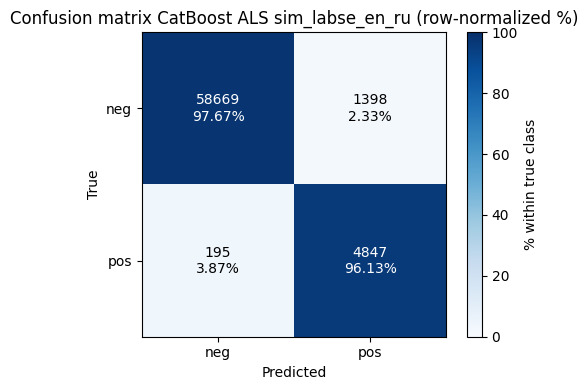

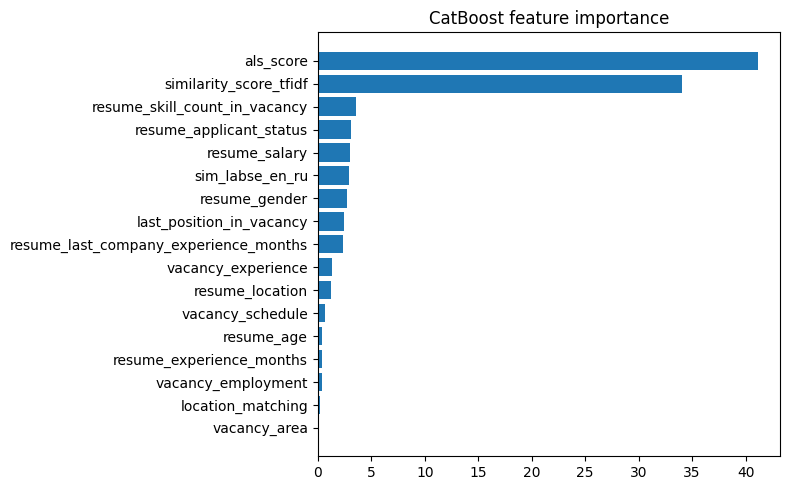

In [71]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_bin)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
for (i, j), v in np.ndenumerate(cm_pct):
    ax.text(j, i, f'{cm[i, j]}\n{v:.2f}%', ha='center', va='center',
            color='white' if v > 50 else 'black')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['neg', 'pos']); ax.set_yticklabels(['neg', 'pos'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion matrix CatBoost ALS {sim_col_best} (row-normalized %)')
fig.colorbar(im, label='% within true class')
cm_path = artifact_dir / 'confusion_matrix.png'
fig.tight_layout(); fig.savefig(cm_path, dpi=120); plt.show()

cb_clf   = pipeline_cb_final.named_steps['model']
fi       = cb_clf.feature_importances_
fi_names = final_features
order    = np.argsort(fi)[::-1]
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.barh([fi_names[i] for i in order][::-1], [fi[i] for i in order][::-1])
ax2.set_title('CatBoost feature importance')
fi_path = artifact_dir / 'feature_importance.png'
fig2.tight_layout(); fig2.savefig(fi_path, dpi=120); plt.show()

sample_predictions = (df_test_cb[['vacancy_id', 'resume_id', 'target', 'y_pred_proba']]
                      .sort_values('y_pred_proba', ascending=False).head(20))
sp_path = artifact_dir / 'predictions_sample.csv'
sample_predictions.to_csv(sp_path, index=False, encoding='utf-8')

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

отправим PRD в MLflow

</div>

In [72]:
registered_model_name = 'hr-ai-scout-prd'
prd_alias             = 'PRD'
final_experiment_name = 'hr-ai-scout-final'

mlflow.set_tracking_uri(f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}')
mlflow.set_registry_uri(f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}')

_exp = mlflow.get_experiment_by_name(final_experiment_name)
final_experiment_id = _exp.experiment_id if _exp else mlflow.create_experiment(final_experiment_name)

signature_cb     = mlflow.models.infer_signature(X_te[:100], y_test[:100])
input_example_cb = X_te[:10]

with mlflow.start_run(run_name='PRD', experiment_id=final_experiment_id) as final_run:
    final_run_id = final_run.info.run_id

    mlflow.log_param('seed',     RANDOM_STATE)
    mlflow.log_param('model',    best['Model'])
    mlflow.log_param('sim_col',  sim_col_best)
    mlflow.log_param('features', str(final_features))

    mlflow.log_metrics(metrics_final)

    mlflow.set_tags({
        'stage':      'PRD',
        'model_type': f'CatBoost+ALS+{best["Model"]}',
        'sim_col':    sim_col_best,
    })

    mlflow.log_artifact(str(cm_path), artifact_path='plots')
    mlflow.log_artifact(str(fi_path), artifact_path='plots')
    mlflow.log_artifact(str(sp_path), artifact_path='predictions')

    model_info = mlflow.sklearn.log_model(
        sk_model=pipeline_cb_final,
        artifact_path='catboost_pipeline',
        registered_model_name=registered_model_name,
        signature=signature_cb,
        input_example=input_example_cb,
        await_registration_for=120,
    )

2026/06/03 21:21:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 21:21:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'hr-ai-scout-prd' already exists. Creating a new version of this model...
2026/06/03 21:21:28 INFO mlflow.store.model_registry.abstract_store: Waiting up to 120 seconds for model version to finish creation. Model name: hr-ai-scout-prd, version 2


🏃 View run PRD at: http://127.0.0.1:5000/#/experiments/2/runs/23125b1be07a4195ae4f87c922878656
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


Created version '2' of model 'hr-ai-scout-prd'.


In [73]:
client = MlflowClient()
client.set_registered_model_alias(
    name=registered_model_name,
    alias=prd_alias,
    version=model_info.registered_model_version,
)

mv = client.get_model_version_by_alias(registered_model_name, prd_alias)
{'name': mv.name, 'alias': prd_alias, 'version': mv.version, 'run_id': mv.run_id}

{'name': 'hr-ai-scout-prd',
 'alias': 'PRD',
 'version': '2',
 'run_id': '23125b1be07a4195ae4f87c922878656'}

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Сравнение с baseline и интерпретация разницы

- Сравниваем финальный CatBoost ALS LaBSE TF-IDF с бейзлайном LogReg TF-IDF по всем основным метрикам
- Разница обусловлена добавлением коллаборативного сигнала ALS и семантических эмбеддингов LaBSE

</div>

In [74]:
bc_path = artifact_dir / 'baseline_comparison.csv'
results_df.to_csv(bc_path, index=False, encoding='utf-8')
client.log_artifact(final_run_id, str(bc_path), artifact_path='comparison')
results_df

,Model,NDCG,Precision,Recall,F1,Delta vs TF-IDF
0,cointegrated/LaBSE-en-ru,0.773123,0.660202,0.753158,0.688969,0.052199
1,LaBSE-hr-finetuned,0.771399,0.703082,0.733030,0.707245,0.050475


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Анализ ошибок

- Выделяем типичные ошибки модели на тестовом сете
- FP: модель выдала оценку выше 0.5, но таргет равен 0, рекрутер кандидата не взял
- FN: модель выдала оценку ниже, но таргет равен 1, кандидат подошел
- Для каждого класса берем топ 10 самых уверенных промахов

</div>

In [75]:
err_cols = [
    'vacancy_id', 'resume_id', 'target',
    'vacancy_area', 'vacancy_experience', 'vacancy_employment',
    'resume_location', 'resume_age', 'resume_experience_months',
    'resume_salary', 'resume_skill_count_in_vacancy',
    'last_position_in_vacancy', 'similarity_score_tfidf',
    'als_score',
]
err_df = df.loc[X_te.index, [c for c in err_cols if c in df.columns]].copy()
err_df['als_score']   = X_te['als_score'].values
err_df[final_sim_col] = X_te[final_sim_col].values
err_df['y_pred_proba'] = proba_te
err_df['y_pred']       = y_pred_bin

fp_df = (err_df[(err_df['target'] == 0) & (err_df['y_pred'] == 1)]
         .sort_values('y_pred_proba', ascending=False).head(10))
fn_df = (err_df[(err_df['target'] == 1) & (err_df['y_pred'] == 0)]
         .sort_values('y_pred_proba', ascending=True).head(10))

errors_df = pd.concat([fp_df.assign(error_type='FP'),
                       fn_df.assign(error_type='FN')])
err_path = artifact_dir / 'error_analysis.csv'
errors_df.to_csv(err_path, index=False, encoding='utf-8')
client.log_artifact(final_run_id, str(err_path), artifact_path='errors')

errors_df.head(20)

,vacancy_id,resume_id,target,vacancy_area,vacancy_experience,vacancy_employment,resume_location,resume_age,resume_experience_months,resume_salary,resume_skill_count_in_vacancy,last_position_in_vacancy,similarity_score_tfidf,als_score,sim_labse_en_ru,y_pred_proba,y_pred,error_type
153755,126399386,68435959,0,Москва,От 3 до 6 лет,Полная занятость,Москва,36.000000,202.0,400000.0,8,1.000000,0.191257,4.431413e-01,0.661842,0.999701,1,FP
122169,126022732,88948254,0,Москва,От 3 до 6 лет,Полная занятость,Москва,46.000000,267.0,0.0,1,0.400000,0.257331,1.840067e-01,0.809480,0.999669,1,FP
157606,126472835,123522852,0,Москва,От 3 до 6 лет,Полная занятость,Москва,28.000000,57.0,250000.0,7,1.000000,0.248765,2.134308e-02,0.822285,0.999617,1,FP
54312,125832490,25156366,0,Москва,Нет опыта,Проектная работа,Москва,44.060813,166.0,30000.0,0,0.500000,0.288146,6.388757e-03,0.661390,0.999563,1,FP
102824,125842165,87053005,0,Москва,От 1 года до 3 лет,Полная занятость,Бишкек,37.000000,166.0,0.0,5,0.333333,0.219069,2.769570e-02,0.718830,0.999356,1,FP
228585,126373989,11612700,0,Москва,От 1 года до 3 лет,Полная занятость,Санкт-Петербург,38.000000,173.0,0.0,3,0.000000,0.248355,5.187730e-02,0.832965,0.999349,1,FP
51852,125490332,7644258,0,Москва,Нет опыта,Полная занятость,Москва,37.000000,219.0,60000.0,0,0.000000,0.251906,1.437444e-01,0.782503,0.999228,1,FP
40543,125321061,140955162,0,Москва,От 1 года до 3 лет,Полная занятость,ОАЭ,39.000000,121.0,0.0,0,0.000000,0.284548,3.056546e-02,0.701479,0.999149,1,FP
235692,126470958,49599247,0,Москва,От 3 до 6 лет,Полная занятость,Москва,45.000000,151.0,0.0,7,0.000000,0.230541,2.477771e-02,0.848810,0.998903,1,FP
27375,126149613,151612872,0,Москва,От 3 до 6 лет,Полная занятость,Москва,27.000000,85.0,0.0,2,1.000000,0.180733,1.152331e-01,0.813337,0.998843,1,FP


In [76]:
err_summary = (
    errors_df.groupby('error_type')
    .agg(
        n=('target', 'size'),
        mean_proba=('y_pred_proba', 'mean'),
        mean_als=('als_score', 'mean'),
        mean_tfidf=('similarity_score_tfidf', 'mean'),
        mean_skill=('resume_skill_count_in_vacancy', 'mean'),
        mean_last_pos=('last_position_in_vacancy', 'mean'),
        mean_age=('resume_age', 'mean'),
        mean_exp=('resume_experience_months', 'mean'),
    )
    .round(3)
)

err_summary_path = artifact_dir / 'error_summary.csv'
err_summary.to_csv(err_summary_path)
client.log_artifact(final_run_id, str(err_summary_path), artifact_path='errors')

err_summary

,n,mean_proba,mean_als,mean_tfidf,mean_skill,mean_last_pos,mean_age,mean_exp
error_type,,,,,,,,
FN,10,0.004,-0.000,0.032,0.3,0.109,37.806,146.8
FP,10,0.999,0.105,0.240,3.3,0.423,37.706,160.7


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

На Confusion матрице можно заметить, что доля FP / FN меньше 5%, что считаю хорошими результатами

Ошибки и причины и и можно ли их скорректировать


- FP - при высоких метриках, а по факту "рекрутер" все равно отказал - "рекрутер" видит детали грейд бэкграунд компании которых нет в фичах, нельзя без расширения признакового пространства, (по факту это была LLM так что просто сыграло наше ограничение на кол-во сосикателей на каждую позицию)
- FP - overconfident ALS, высокий als score, кандидат уже откликался на похожие вакансии, ALS помнит популярных кандидатов, но они не подходят под конкретную вакансию
- FN пустое поле, нулевой или низкий als score, пустой last position in vacancy, короткое resume last experience description, у кандидата мало текстовой информации и модель не может построить устойчивое предсказание, нельзя на этих данных нужны более богатые резюме
- FN - гео несоответствие, location matching равен 0, но рекрутер все равно взял релокация или удаленка, модель штрафует за несовпадение локации, рекрутер нет, можно отдельно обрабатывать vacancy schedule
- FN - нетипичная должность, низкая схожесть, но "рекрутер" увидел смежные навыки, TF-IDF и LaBSE плохо схватывают переход между разными ролями например аналитик в ML-инженер

</div>

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- MAE на оценке около 2,6%, значит, что модель почти не меняет уверенность при атаках на текст
- Смена класса только у 2-3%, что совсем не критично. Задача отобрать и ранжировать
- Копипаст вакансии в опыт кандидата не работает как читинг
- Случайный чужой опыт дает такую же реакцию как и осмысленная атака, модель опирается не на текст, а на числовые признаки и ALS
- Поведение устойчивое, текстовый канал не доминирует

</div>

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Robustness: оцениваем как изменение в данных влияет на предсказания

Проверка на читинг:
- Берем случайную подвыборку из тестового сета и модифицируем разными способами
- Дублирование описания вакансии в опыт кандидата много раз, как самый очевидный способ накрутить фичи
- Просто вставка описания вакансии в опыт кандидата один раз
- Замена опыта на случайный текст того же кандидата, чтобы оценить шум
- Для каждой модификации пересчитываем метрики, смотрим на результат

</div>

In [77]:
rng = np.random.RandomState(RANDOM_STATE)
n_sample   = min(200, len(X_te))
sample_pos = rng.choice(len(X_te), size=n_sample, replace=False)

sample_index = X_te.index[sample_pos]
df_sample    = df.loc[sample_index, [
    'vacancy_id', 'resume_id',
    'vacancy_description', 'resume_last_experience_description',
    'resume_last_position', 'resume_skills',
]].copy()

x_robust_base = X_te.iloc[sample_pos].copy()
proba_base    = pipeline_cb_final.predict_proba(x_robust_base)[:, 1]

_bert_name = BERT_MODELS[0][0]
_tok_rob   = AutoTokenizer.from_pretrained(_bert_name)
_mdl_rob   = AutoModel.from_pretrained(_bert_name).to(DEVICE).eval()


def _bert_sim(vacancy_texts, resume_texts):
    vac_emb = encode_texts(list(vacancy_texts), _tok_rob, _mdl_rob, batch_size=64)
    res_emb = encode_texts(list(resume_texts),  _tok_rob, _mdl_rob, batch_size=64)
    return (vac_emb * res_emb).sum(axis=1).astype(np.float32)


def _apply_mod(df_part):
    x_mod = x_robust_base.copy()
    x_mod[final_sim_col] = _bert_sim(
        df_part['vacancy_description'].fillna('').astype(str).tolist(),
        df_part['resume_last_experience_description'].fillna('').astype(str).tolist(),
    )
    x_mod['resume_skill_count_in_vacancy'] = df_part.apply(
        resume_skill_count_in_vacancy, axis=1).values
    x_mod['last_position_in_vacancy'] = df_part.apply(
        last_position_in_vacancy, axis=1).values
    return x_mod


robustness_results = {}

df_mod1 = df_sample.copy()
df_mod1['resume_last_experience_description'] = (
    df_mod1['vacancy_description'].fillna('').astype(str) * 10)
proba_p1 = pipeline_cb_final.predict_proba(_apply_mod(df_mod1))[:, 1]
robustness_results['duplicate_vacancy_x10_into_experience'] = float(
    np.mean(np.abs(proba_p1 - proba_base)))

df_mod2 = df_sample.copy()
df_mod2['resume_last_experience_description'] = (
    df_mod2['resume_last_experience_description'].fillna('').astype(str)
    + ' ' + df_mod2['vacancy_description'].fillna('').astype(str))
proba_p2 = pipeline_cb_final.predict_proba(_apply_mod(df_mod2))[:, 1]
robustness_results['append_vacancy_to_experience_x1'] = float(
    np.mean(np.abs(proba_p2 - proba_base)))

df_mod3 = df_sample.copy()
df_mod3['resume_last_experience_description'] = (
    df_sample['resume_last_experience_description']
    .sample(frac=1, random_state=RANDOM_STATE).values)
proba_p3 = pipeline_cb_final.predict_proba(_apply_mod(df_mod3))[:, 1]
robustness_results['shuffle_experience_random'] = float(
    np.mean(np.abs(proba_p3 - proba_base)))

del _tok_rob, _mdl_rob
import gc; gc.collect()

for k, v in robustness_results.items():
    client.log_metric(final_run_id, f'robustness_{k}', v)

robustness_results

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/LaBSE-en-ru
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    encoding:   0%|          | 0/4 [00:00<?, ?it/s]

    encoding:   0%|          | 0/4 [00:00<?, ?it/s]

    encoding:   0%|          | 0/4 [00:00<?, ?it/s]

    encoding:   0%|          | 0/4 [00:00<?, ?it/s]

    encoding:   0%|          | 0/4 [00:00<?, ?it/s]

    encoding:   0%|          | 0/4 [00:00<?, ?it/s]

{'duplicate_vacancy_x10_into_experience': 0.007120284616400979,
 'append_vacancy_to_experience_x1': 0.006650439801673362,
 'shuffle_experience_random': 0.006244379953379135}

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Модель устойчива даже при экстремальном читинге предсказания меняются всего на 0.7%
- Семантические эмбеддинги не перевешивают остальные фичи

</div>
